# Counting Gaia quantities with Spark SQL

This notebook uses Spark SQL to summarize selected Gaia DR3 source quantities as a function of Gaia `G` magnitude. The examples focus on quick, science-facing diagnostics:

- the fraction of sources with measured radial velocities in each magnitude bin,
- an approximate count of sources with radial velocities in the selected magnitude range,
- the average parallax uncertainty by magnitude,
- and the number of stars contributing to each magnitude bin.

The queries aggregate in Spark and only collect the binned summaries back to pandas, which keeps the notebook interactive while the large Gaia table stays distributed.

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np

## Attach to the Gaia Spark session

The notebook expects `astroflow_spark_gaia` to provide a configured Spark session with the Gaia DR3 catalog registered as `gaiadr3.gaia_source`. Keep the cluster-specific configuration in that setup module so the analysis cells can stay focused on the scientific questions.

In [2]:
# Import the spark config
from astroflow_spark_gaia import spark

Beginning the initilization of a spark cluster with 10 pods, 5 cores/pod and 7g mem/pod


26/08/18 11:03:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/18 11:03:04 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).
26/08/18 11:03:05 WARN Utils: Service 'sparkDriver' could not bind on port 41730. Attempting port 41731.
26/08/18 11:03:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/08/18 11:03:06 WARN Utils: Service 'org.apache.spark.network.netty.NettyBlockTransferService' could not bind on port 51730. Attempting port 51731.


Completed initialisation
Setting up SparkSQL
Setting up dataset Gaia DR3 with 4 databases gaiadr3, gaiadr3ssd, gaiaedr3ssd, gaiaedr3
Read default database gaiadr3ssd from environment config
A spark cluster has been sucessfully set up, you can interact with it via the "spark" object


## Radial-velocity coverage by magnitude

This query bins sources by `phot_g_mean_mag` in 0.2 mag intervals, then computes the fraction of sources in each bin with a finite `radial_velocity`. The result is small enough to collect with `toPandas()` because the large table has already been reduced to one row per magnitude bin.

In [3]:
query = """
SELECT
    FLOOR(phot_g_mean_mag * 5) / 5.0 AS mag_bin,
    AVG(
        CASE
            WHEN radial_velocity IS NOT NULL
                 AND NOT isnan(radial_velocity)
            THEN 1.0
            ELSE 0.0
        END
    ) AS rv_fraction,
    COUNT(*) AS n_stars
FROM gaiadr3.gaia_source
WHERE phot_g_mean_mag >= 4
  AND phot_g_mean_mag < 19
GROUP BY FLOOR(phot_g_mean_mag * 5) / 5.0
ORDER BY mag_bin
"""

_t1 = time.time()
rv_fraction_by_bin = spark.sql(query)

rv_fraction_by_bin_pd = rv_fraction_by_bin.toPandas()

print('Time elapsed: ',time.time()-_t1)

Time elapsed:  44.3853645324707


## Plot the radial-velocity selection function

The line plot shows how Gaia radial-velocity availability changes with apparent magnitude. This is a useful quick check before building samples that depend on RVS measurements, because the selection function is strongly magnitude-dependent.

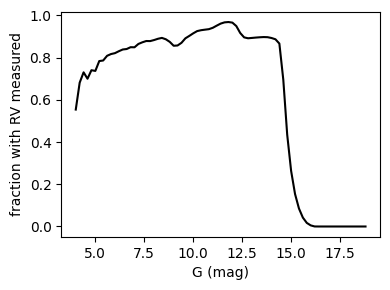

In [4]:
plt.figure(figsize=(4,3))
plt.plot(rv_fraction_by_bin_pd['mag_bin'],rv_fraction_by_bin_pd['rv_fraction'],color='black')
plt.xlabel('G (mag)')
plt.ylabel('fraction with RV measured')
plt.tight_layout()
#plt.savefig('rv_fraction.png',dpi=300)

## Model the radial-velocity selection function

Using this data, we can make a model with a simple probability estimate for whether a star will have an RVS measurement based on magnitude. The model

1. Fits the shape of the curve for the RV measurements: flat when brighter than some pivot some magnitude, and then error function falloff.
2. Assume that the width of the falloff will not change, but the pivot magnitude will for DR4.

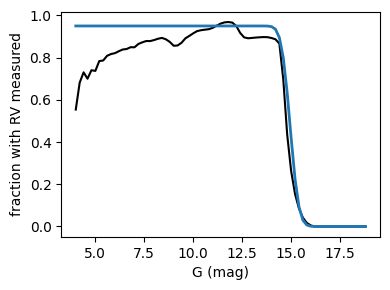

In [5]:
from scipy.special import erf

# Adjust these model parameters
pivot_mag = 14.95
dr4offset = 2.6 # how many more mags of depth?
width_mag = 0.35  # Gaussian-equivalent sigma in magnitudes

mag = rv_fraction_by_bin_pd["mag_bin"].to_numpy(dtype=float)

def rv_obs_probability(mag, pivot, width, flatfrac=0.95):
    """Bright-end probability -> 1; faint-end probability -> 0."""
    return flatfrac * 0.5 * (1.0 - erf((mag - pivot) / (np.sqrt(2.0) * width)))

mag_grid = rv_fraction_by_bin_pd["mag_bin"].values.astype('float')
p_obs = rv_obs_probability(mag_grid, pivot_mag, width_mag)
p_obs_dr4 = rv_obs_probability(mag_grid, pivot_mag + dr4offset, width_mag)


plt.figure(figsize=(4,3))
plt.plot(rv_fraction_by_bin_pd['mag_bin'],rv_fraction_by_bin_pd['rv_fraction'],color='black')
plt.plot(mag_grid, p_obs, lw=2, label=fr"$m_0={pivot_mag:.1f},\ \sigma={width_mag:.1f}$")

plt.xlabel('G (mag)')
plt.ylabel('fraction with RV measured')
plt.tight_layout()
#plt.savefig('rv_fraction.png',dpi=300)

## Estimate the number of radial-velocity sources

Multiplying the number of stars in each bin by the measured radial-velocity fraction gives an approximate total count over the selected magnitude range. This should agree with the SQL aggregation up to binning and null-handling choices.

We also can check the number our model would return, and the possible increase for DR4.

In [6]:
print('Actual number of DR3 RV sources tabulated:',int((np.nansum(rv_fraction_by_bin_pd['rv_fraction']*rv_fraction_by_bin_pd['n_stars']))))
print('Predicted number of DR3 RV sources:',int((np.nansum(p_obs*rv_fraction_by_bin_pd['n_stars']))))
print('Predicted number of DR4 RV sources:',int((np.nansum(p_obs_dr4*rv_fraction_by_bin_pd['n_stars']))))


Actual number of DR3 RV sources tabulated: 33810838
Predicted number of DR3 RV sources: 37695472
Predicted number of DR4 RV sources: 236766997


## Average parallax uncertainty by magnitude

This second query uses the same 0.2 mag binning pattern, but summarizes `parallax_error` instead of radial-velocity availability. Averaging only finite parallax uncertainties gives a compact view of how astrometric precision changes across the Gaia magnitude range.

In [7]:
query = """
SELECT
    FLOOR(phot_g_mean_mag * 5) / 5.0 AS mag_bin,
    AVG(
        CASE
            WHEN parallax_error IS NOT NULL
                 AND NOT isnan(parallax_error)
            THEN parallax_error
        END
    ) AS parallax_error_average,
    COUNT(*) AS n_stars
FROM gaiadr3.gaia_source
WHERE phot_g_mean_mag >= 4
  AND phot_g_mean_mag < 21
GROUP BY FLOOR(phot_g_mean_mag * 5) / 5.0
ORDER BY mag_bin
"""

_t1 = time.time()
parallax_by_bin = spark.sql(query)

parallax_by_bin_pd = parallax_by_bin.toPandas()

print('Time elapsed: ',time.time()-_t1)

Time elapsed:  40.05324983596802


## Plot parallax uncertainty

The parallax uncertainty is shown on a log scale so the trend remains readable over the full magnitude range. This plot is a quick way to see where the catalog transitions from high-precision bright sources to fainter sources with larger astrometric uncertainties.

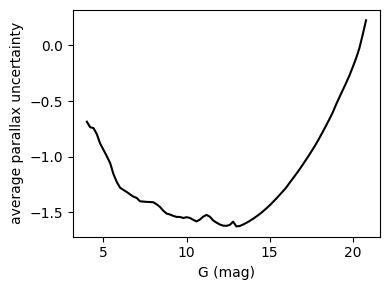

In [8]:
plt.figure(figsize=(4,3))
plt.plot(parallax_by_bin_pd['mag_bin'],np.log10(parallax_by_bin_pd['parallax_error_average']),color='black')
plt.xlabel('G (mag)')
plt.ylabel('average parallax uncertainty')
plt.tight_layout()
#plt.savefig('parallax_uncertainty_average.png',dpi=300)

## Plot the number of sources per bin

The star-count curve gives context for the uncertainty trend: bins with many more sources can dominate downstream summaries, while sparsely populated bright bins may show noisier aggregate behavior.

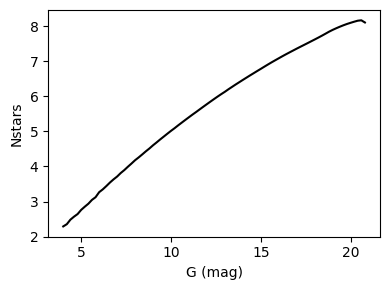

In [9]:
plt.figure(figsize=(4,3))
plt.plot(parallax_by_bin_pd['mag_bin'],np.log10(parallax_by_bin_pd['n_stars']),color='black')
plt.xlabel('G (mag)')
plt.ylabel('Nstars')
plt.tight_layout()
#plt.savefig('parallax_uncertainty_average.png',dpi=300)

## Next steps

These binned summaries are intended as fast exploratory diagnostics. Natural extensions include adding color or sky-position bins, replacing averages with robust percentiles, or writing the aggregated tables to a small output file for comparison across Spark configurations.